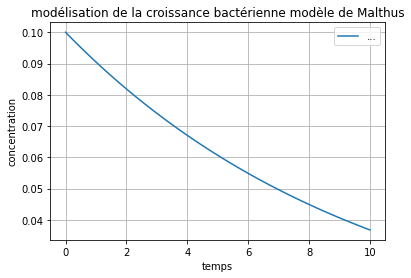

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = -0.1 # taux de croissance maximal (h⁻¹)
C0 = 0.1 # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)
# Tracé du graphique
plt.title('modélisation de la croissance bactérienne modèle de Malthus') # Titre du graphique
plt.plot(time, C, label='...') # Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

C'est une courbe exponentielle.
La population double environ vers 3,5 heures.
A la valeur de rmax à 0.4 la courbe montre une croissance exponentielle rapide de la pop. bactérienne 
A la valeur 0.1 la courbe montre une courbe linéaire 
A 0 la population n'evolue pas et à -0.1, on observe une décroissance. 
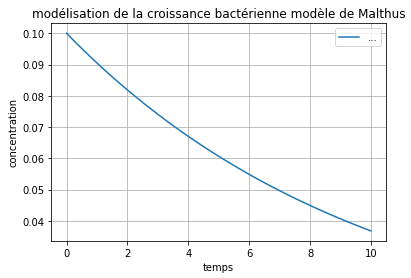
Les limites de ce modèle suppose des ressources infinies, absence de déchets, espaces illimités, taux constant et aucune mortalité. Pour le rendre plus réaliste il faudrait ajouter une capacité limite du milieu, la mortalité et des des contraintes environnementales, ce qui conduit à un modèle logistique avec une croissance sigmoïde.

In [ ]:
question 2) ![image.png](attachment:image.png)
question 4) ![image-2.png](attachment:image-2.png)
question 4) ![image-3.png](attachment:image-3.png)


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = - 0,1 # taux de croissance maximal (h⁻¹)
C0 = 0.1 # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)
# Tracé du graphique
plt.title('modélisation de la croissance bactérienne modèle de Malthus') # Titre du graphique
plt.plot(time, C, label='...') # Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

ValueError: operands could not be broadcast together with shapes (2,) (100,) 

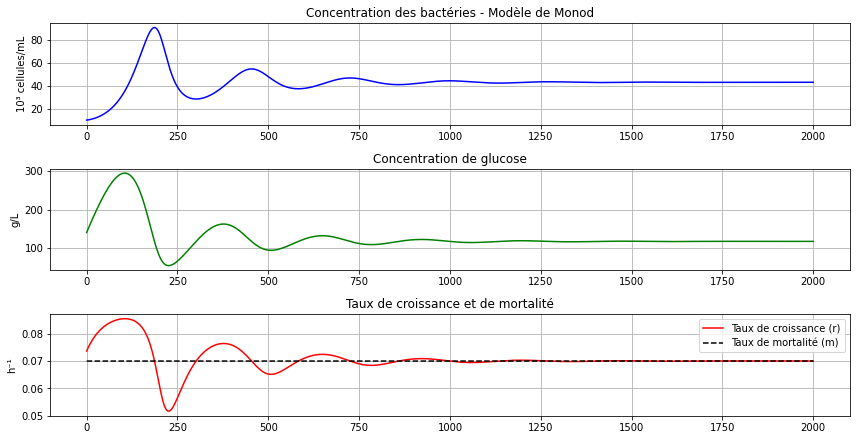

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 2000          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 140  # Concentration initiale de glucose (g/L)
glucose_inflow = 3     # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]
# Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()


1.Courbe des bactéries : La population augmente d'abord fortement car le glucose est abondant. Elle atteint un maximum vesr 170-180h, puis elle diminue fortement, puis elle diminue fortement.

Courbe du glucose : La concentration en glucose diminue progressivement, car il est consommé par les bactéries.Elle devient très faible vers la fin.

Taux de croissance et de mortalité : Au début, r sup à m donc pop. augmente. ensuite le glucose diminue donc r baisse. quand R=M, la pop. atteint son maximum. Après, r inf à m, donc la pop. diminue.

La pop. s'écrule car le glucose est épuisé. Les bactéries n'ony plus assez de substrat énergétique pour se divsier. Leur taux de croissance devient inférieur au taux de mortalité.
Le facteur limitant est le glucose.

2.r = 0.07 h^-1

3.Graphiquement, quand r = 0.05, la concentration en glucose vaut environ : K = 50 g/L 

Pour que la population bactérienne se maintienne dans le temps, il faudrait ajouter un flux entrant constant de glucose afin de compenser sa consommation par des bactéries. Cela permettrait de maintenir un taux de croissance réel r proche du taux de mortalité m, et donc d'obtenir une pop. stable. 

Dans un second temps : 

1.Description des courbes : 

La population augmente d’abord très fortement jusqu’à un pic vers 180–200 h. Ensuite, elle chute, puis remonte plusieurs fois avec des oscillations de plus en plus faibles. À long terme, elle finit par se stabiliser autour d’une valeur d’équilibre.

Courbe du glucose :
Le glucose augmente au début grâce au flux entrant constant, puis il chute fortement quand les bactéries deviennent nombreuses et le consomment rapidement. Ensuite, il oscille aussi, avant de se stabiliser progressivement.

Courbe de r et m :
Le taux de croissance r varie avec la quantité de glucose. Quand le glucose augmente, r augmente. Quand le glucose diminue, r diminue. À long terme, r se rapproche du taux de mortalité m.

2.Pourquoi il y a des fluctuations ?

La population fluctue car il y a un décalage entre la disponibilité du glucose et la réponse de la population bactérienne.

Quand il y a beaucoup de glucose :

r > m

la population augmente rapidement.

Mais comme il y a beaucoup de bactéries, elles consomment beaucoup de glucose. Le glucose chute, donc :

r < m

la population diminue.

Quand la population diminue, elle consomme moins de glucose. Le glucose remonte grâce au flux entrant, donc r réaugmente. Cela provoque une nouvelle croissance bactérienne.

3.Pourquoi la population se stabilise ?

Elle se stabilise car le système atteint un équilibre entre :

    l’apport constant de glucose,
    la consommation de glucose par les bactéries,
    la croissance bactérienne,
    la mortalité.

À l’équilibre :

r approx m

Donc la population ne monte plus fortement et ne s’écroule plus.

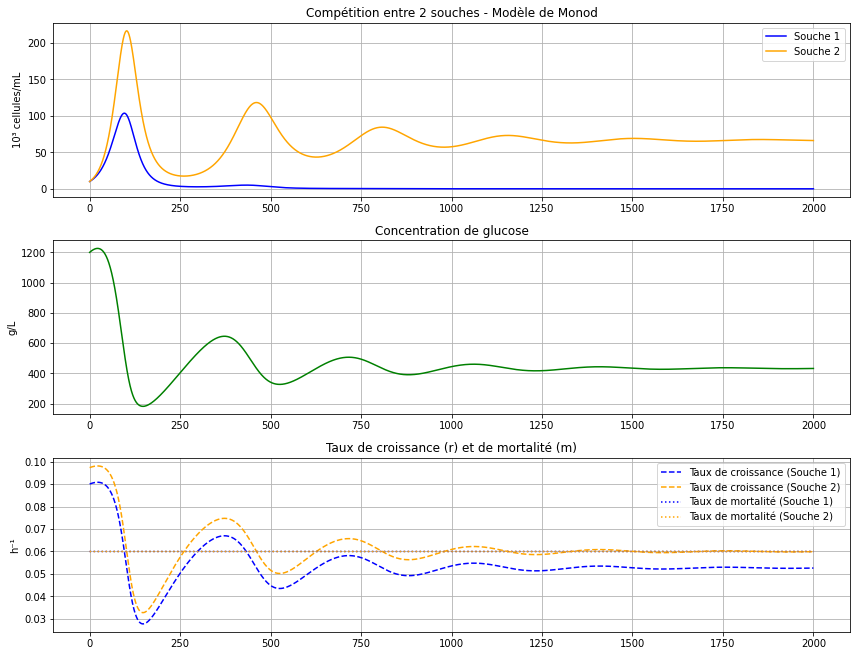

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)
# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

1.Description des courbes

Population bactérienne :
Les deux souches augmentent au début, car le glucose est abondant. Ensuite, elles présentent des oscillations. La souche 2 atteint des valeurs beaucoup plus élevées que la souche 1, puis se stabilise. La souche 1 diminue fortement et reste presque nulle.

Glucose :
Le glucose chute fortement au début car les deux souches le consomment rapidement. Ensuite, il remonte puis oscille avant de se stabiliser.

Taux de croissance et mortalité :
La souche 2 garde un taux de croissance plus élevé que la souche 1, car son K est plus faible. Elle utilise donc mieux le glucose. La mortalité est identique pour les deux souches.
2.Résultat de la concurrence

La souche 2 l’emporte sur la souche 1.

Comme :

K_2 = 650 < K_1 = 800

la souche 2 a une meilleure affinité pour le glucose. Elle exploite mieux la ressource limitante, donc elle se développe davantage et prend le dessus.

La souche 1 est presque éliminée par compétition.

Dans cette simulation, les deux souches sont en compétition pour le même substrat limitant : le glucose. La souche 2 possède une meilleure affinité pour ce substrat car son K est plus faible. Elle maintient donc un taux de croissance supérieur à celui de la souche 1, surtout lorsque le glucose devient limitant. La concurrence aboutit à la domination de la souche 2, tandis que la souche 1 régresse fortement. Cela illustre une sélection naturelle : la souche la mieux adaptée à l’environnement devient majoritaire.

Les deux souches coexistent si leurs paramètres biologiques sont proches (rmax, K, mortalité) et si les ressources sont suffisamment renouvelées. Si une souche exploite nettement mieux le glucose ou possède une mortalité plus faible, elle finit par exclure l’autre par compétition.

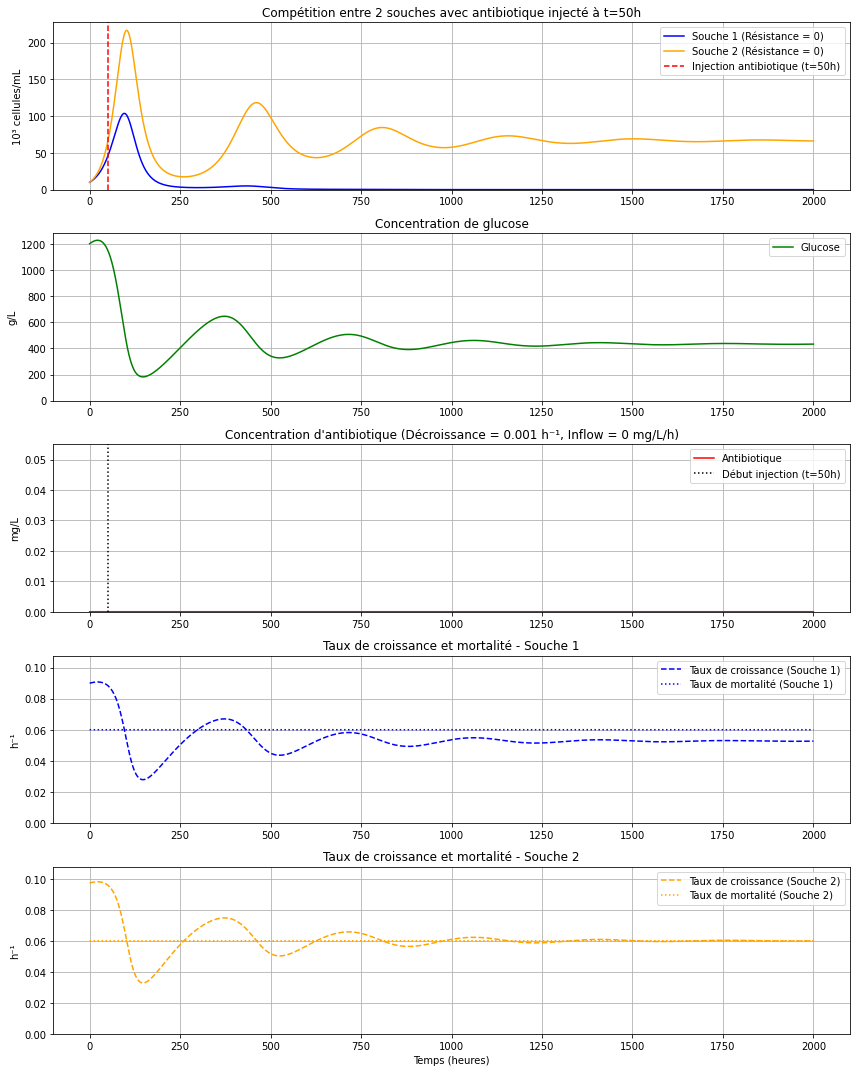

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.06       # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.06        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 4      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 00   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.001    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 2000        # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=50h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()


Note : Pour la question 1 le prof nous a demander de changer dans les parametres de simulation T = 2000 À t = 200H. Cela ne change pas le modèle, mais permet de mieux visualier la phase initiale. Cette visualisation montre que la souche 2 est dominante par rapport à la souche 1. Si on modifie m0_1 de 0.06 à 0.04 on voit que la souche 1 devient dominante lorsque ses paramètres lui donnent un avantge, notamment une mortalité plus faible

La souche 2 augmente fortement et atteint des pics beaucoup plus élevés que la souche 1. Elle domine ensuite durablement la population. La souche 1 augmente au début, puis chute fortement et reste presque nulle.

Cela s’explique par le fait que la souche 2 possède une meilleure affinité pour le glucose : son K est plus faible, donc elle utilise mieux le substrat limitant. Le glucose chute au début car il est consommé massivement, puis il oscille avant de se stabiliser.

Conclusion : ici, la sélection favorise surtout la souche 2 grâce à sa meilleure exploitation du glucose, pas grâce à l’antibiotique.
2.Avec initial_antibiotic = 10

Quand l’antibiotique est injecté à t = 50h, la mortalité des deux souches augmente, car elles ont toutes les deux une résistance nulle.

La population des deux souches diminue davantage après l’injection. Cependant, comme la souche 2 utilise mieux le glucose, elle garde un avantage global. L’antibiotique réduit les populations, mais ne sélectionne pas une souche résistante puisqu’aucune des deux ne l’est.

Conclusion : l’antibiotique exerce une pression négative sur les deux souches, mais la souche 2 reste avantagée par son meilleur K.
3.Avec resistance_1 = 1

La souche 1 devient totalement résistante. L’antibiotique n’augmente donc plus sa mortalité. La souche 2, elle, reste sensible.

Même si la souche 1 utilise moins bien le glucose, elle est protégée contre l’antibiotique. Elle peut donc se maintenir, voire devenir dominante, car la souche 2 est fortement pénalisée par l’antibiotique.

Conclusion : l’antibiotique inverse la sélection : il favorise la souche résistante.
4.Avec resistance_1 = 0.2

La souche 1 est seulement faiblement résistante. Elle subit encore l’effet de l’antibiotique, mais moins que la souche 2.

La souche 2 garde son avantage sur le glucose, mais cet avantage est réduit par sa sensibilité à l’antibiotique. La souche 1 survit donc mieux qu’avant, mais elle ne devient pas forcément totalement dominante.

Conclusion : une faible résistance améliore la survie de la souche 1, mais l’équilibre dépend de l’intensité de l’antibiotique et de l’avantage de la souche 2 sur le glucose.
5.Avec antibiotic_inflow = 0.02

L’antibiotique arrive en continu dans le milieu. La pression de sélection devient durable.

Les souches sensibles sont constamment pénalisées. Une souche résistante, même faiblement, devient progressivement avantagée sur le long terme. Cette situation est plus dangereuse biologiquement car elle favorise le maintien et la sélection des résistances.


Ces simulations montrent que la sélection naturelle dépend de l’environnement. Sans antibiotique, la souche la plus efficace pour utiliser le glucose est sélectionnée. Avec antibiotique, une souche résistante peut être favorisée, même si elle est moins performante pour exploiter le glucose. L’antibiotique agit donc comme une pression de sélection qui modifie le devenir des populations bactériennes. C'est un phénomène de compétitivité.



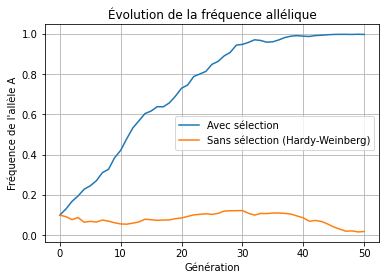

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation
TAILLE_POP = 1000
GENERATIONS = 50

# Fréquence initiale de l'allèle A
freq_A_initiale = 0.1

# Valeurs sélectives (fitness)
# Cas 1 : sélection (ex : antibiotique ou stress)
fitness_selection = {"AA": 1.0,
                     "Aa": 0.9,
                     "aa": 0.7}
# Cas 2 : pas de sélection (équilibre de Hardy-Weinberg)
fitness_neutre = {"AA": 1.0,
                  "Aa": 1.0,
                  "aa": 1.0}

# Génération d'une population
def generer_population(freq_A, taille):
    freq_a = 1 - freq_A
    probabilites = [
        freq_A ** 2,          # AA
        2 * freq_A * freq_a,  # Aa
        freq_a ** 2           # aa
    ]
    return np.random.choice(["AA", "Aa", "aa"], size=taille, p=probabilites)

# Calcul de la fréquence allélique
def calcul_freq_A(population):
    nb_A = sum(genotype.count("A") for genotype in population)
    return nb_A / (2 * len(population))

# Application de la sélection
def appliquer_selection(population, fitness):
    poids = [fitness[g] for g in population]
    total = sum(poids)
    probabilites = [p / total for p in poids]
    return np.random.choice(population, size=len(population), p=probabilites)

# Simulation de l'évolution
def simuler(fitness):
    freq_A = freq_A_initiale
    frequences = [freq_A]  # Initialisation de la liste
    population = generer_population(freq_A, TAILLE_POP)
    for i in range(GENERATIONS):
        population = appliquer_selection(population, fitness)
        freq_A = calcul_freq_A(population)
        population = generer_population(freq_A, TAILLE_POP)
        frequences.append(freq_A)
    return frequences

# Lancement des simulations
freq_selection = simuler(fitness_selection)
freq_neutre = simuler(fitness_neutre)

# Tracé des courbes
plt.figure()
plt.plot(freq_selection, label="Avec sélection")
plt.plot(freq_neutre, label="Sans sélection (Hardy-Weinberg)")
plt.xlabel("Génération")
plt.ylabel("Fréquence de l'allèle A")
plt.title("Évolution de la fréquence allélique")
plt.legend()
plt.grid(True)
plt.show()


Au départ, la fréquence de l’allèle A est faible :

f(A)=0,1

Dans la courbe avec sélection, la fréquence de l’allèle A augmente rapidement au fil des générations. Elle passe d’environ 0,1 à presque 1 en 50 générations. Cela signifie que l’allèle A devient progressivement majoritaire, puis presque fixé dans la population.

Cette augmentation s’explique par les valeurs sélectives :

AA = 1,0, Aa = 0,9, aa = 0,7

Les individus porteurs de l’allèle A ont donc une meilleure fitness que les individus aa. Ils survivent ou se reproduisent davantage, ce qui augmente la fréquence de A génération après génération.

Dans la courbe sans sélection, la fréquence de l’allèle A reste globalement faible, autour de sa valeur initiale, avec de petites variations aléatoires. Ces fluctuations sont dues à la dérive génétique, c’est-à-dire au hasard dans la reproduction et l’échantillonnage des individus.

La sélection naturelle favorise l’allèle A, qui devient presque fixé dans la population. En absence de sélection, la fréquence allélique varie surtout au hasard et reste beaucoup plus proche de sa valeur initiale. Cette simulation montre donc que la sélection peut modifier rapidement la composition génétique d’une population, alors que la dérive génétique provoque surtout des fluctuations aléatoires.